In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
inicial = (
    pl.scan_parquet(r"C:\Users\diogo.durao\Documents\202501_NovoBolsaFamilia.parquet")
    .rename({
        'M�S COMPET�NCIA': 'MES_COMPETENCIA',
        'M�S REFER�NCIA': 'MES_REFERENCIA',
        'C�DIGO MUNIC�PIO SIAFI': 'CODIGO_MUNICIPIO_SIAFI',
        'NOME MUNIC�PIO': 'NOME_MUNICIPIO',
    })
    .with_columns(
        pl.col("VALOR PARCELA")
        .str.replace(",", ".")   
        .cast(pl.Float64)          
    )
)

display(inicial.collect())

MES_COMPETENCIA,MES_REFERENCIA,UF,CODIGO_MUNICIPIO_SIAFI,NOME_MUNICIPIO,CPF FAVORECIDO,NIS FAVORECIDO,NOME FAVORECIDO,VALOR PARCELA
i64,i64,str,i64,str,str,i64,str,f64
202501,202308,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0
202501,202309,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0
202501,202310,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0
202501,202311,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0
202501,202312,"""SP""",7071,"""SANTOS""","""***.085.106-**""",20643890445,"""FERNANDA RAMOS TEIXEIRA""",650.0
…,…,…,…,…,…,…,…,…
202501,202501,"""TO""",9643,"""XAMBIOA""","""""",16640890691,"""ZEIA DE SOUZA LUCIO""",750.0
202501,202501,"""TO""",9643,"""XAMBIOA""","""***.273.191-**""",20644881997,"""ZENILDE ALVES DOS SANTOS""",600.0
202501,202501,"""TO""",9643,"""XAMBIOA""","""""",19058661973,"""ZENOLIA RAMOS DA SILVA CARVALH…",600.0


In [3]:
"""Métricas: Média, Mediana, Moda, Variância, Desvio Padrão, Amplitude"""

# Construindo a expressão de cálculo
metricas1 = inicial.select([
    pl.col("VALOR PARCELA").mean().alias("Média"),
    pl.col("VALOR PARCELA").median().alias("Mediana"),
    # Moda retorna uma lista, pegamos o primeiro valor
    pl.col("VALOR PARCELA").mode().first().alias("Moda"),
    pl.col("VALOR PARCELA").var().alias("Variância"),
    pl.col("VALOR PARCELA").std().alias("Desvio_Padrão"),
    (pl.col("VALOR PARCELA").max() - pl.col("VALOR PARCELA").min()).alias("Amplitude_Total")
]).collect()

print("\n--- Estatísticas Descritivas (Valor do Benefício) ---")
display(metricas1)


--- Estatísticas Descritivas (Valor do Benefício) ---


Média,Mediana,Moda,Variância,Desvio_Padrão,Amplitude_Total
f64,f64,f64,f64,f64,f64
670.023784,650.0,600.0,36439.097638,190.890276,3913.0


In [4]:
'''Forma e Posição: Assimetria, Curtose e Quartis'''

metricas2 = inicial.select([
    pl.col("VALOR PARCELA").quantile(0.25).alias("Q1"),
    pl.col("VALOR PARCELA").quantile(0.50).alias("Q2"),
    pl.col("VALOR PARCELA").quantile(0.75).alias("Q3"),
    pl.col("VALOR PARCELA").skew().alias("Assimetria"),
    pl.col("VALOR PARCELA").kurtosis().alias("Curtose")
]).collect()

print("\n--- Quartis e Forma da Distribuição ---")
display(metricas2)

# Análise rápida da Assimetria
assimetria = metricas2["Assimetria"][0]
print(f"\nInterpretação da Assimetria ({assimetria:.2f}):")
if -0.5 <= assimetria <= 0.5:
    print("-> Distribuição Simétrica (Dados bem balanceados)")
elif assimetria > 0.5:
    print("-> Assimétrica Positiva (Cauda para a direita - Existem valores muito altos puxando a média)")
else:
    print("-> Assimétrica Negativa (Cauda para a esquerda)")


--- Quartis e Forma da Distribuição ---


Q1,Q2,Q3,Assimetria,Curtose
f64,f64,f64,f64,f64
600.0,650.0,750.0,0.926063,4.72103



Interpretação da Assimetria (0.93):
-> Assimétrica Positiva (Cauda para a direita - Existem valores muito altos puxando a média)


In [5]:
'''Outliers'''

# 1. Recuperar os valores de Q1 e Q3 calculados acima
Q1 = metricas2["Q1"][0]
Q3 = metricas2["Q3"][0]
IQR = Q3 - Q1

# 2. Definir limites
limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"\nLimites para Outliers: Inferior ({limite_inferior}) | Superior ({limite_superior})")

# 3. Filtrar e contar os Outliers usando Polars
outliers = inicial.filter(
    (pl.col("VALOR PARCELA") < limite_inferior) |
    (pl.col("VALOR PARCELA") > limite_superior)
).select(["NOME_MUNICIPIO", "NIS FAVORECIDO", "VALOR PARCELA"]).collect()

print(f"Quantidade de pagamentos considerados Outliers: {outliers.height}")
print("Exemplos de valores discrepantes:")
display(outliers.head())


Limites para Outliers: Inferior (375.0) | Superior (975.0)
Quantidade de pagamentos considerados Outliers: 2648673
Exemplos de valores discrepantes:


NOME_MUNICIPIO,NIS FAVORECIDO,VALOR PARCELA
str,i64,f64
"""PIRASSUNUNGA""",16017425650,1010.0
"""PIRASSUNUNGA""",16017425650,1010.0
"""PIRASSUNUNGA""",16017425650,1010.0
"""ITANHAEM""",16451295915,1102.0
"""PIRASSUNUNGA""",16017425650,1010.0


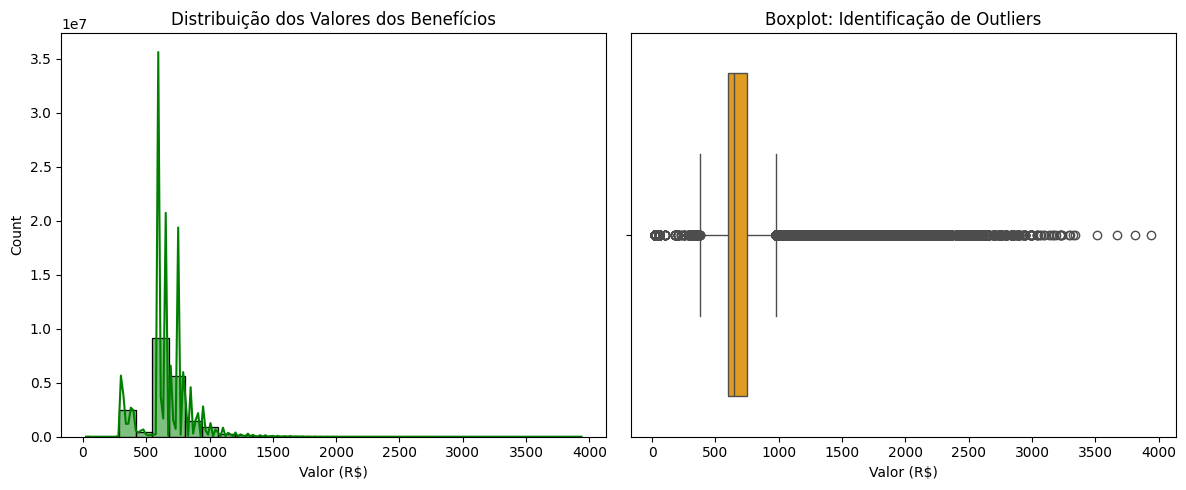

In [6]:

"""Visualização"""

# Coletando a coluna para plotagem
visual = inicial.select("VALOR PARCELA").collect().to_series()

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(visual, bins=30, kde=True, color='green')
plt.title('Distribuição dos Valores dos Benefícios')
plt.xlabel('Valor (R$)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=visual, color='orange')
plt.title('Boxplot: Identificação de Outliers')
plt.xlabel('Valor (R$)')

plt.tight_layout()
plt.show()

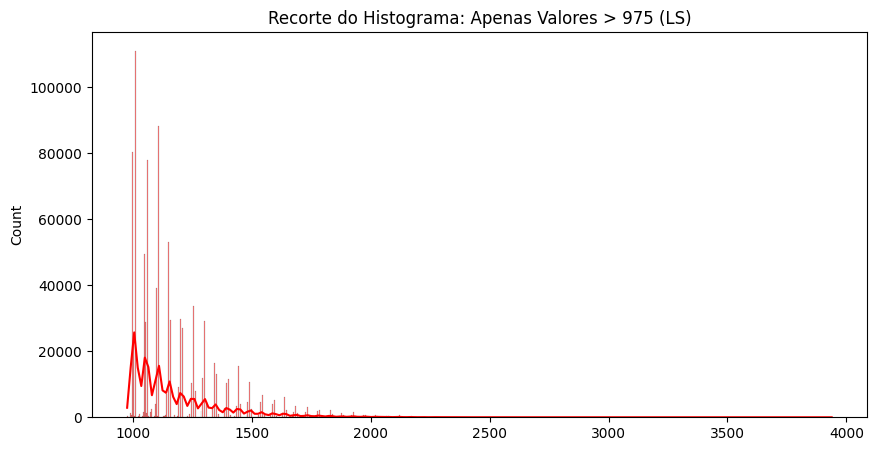

In [7]:
visual_superiores = inicial.filter(pl.col("VALOR PARCELA") > 975).select("VALOR PARCELA").collect().to_series()

plt.figure(figsize=(10, 5))
sns.histplot(visual_superiores, kde=True, color='red')
plt.title('Recorte do Histograma: Apenas Valores > 975 (LS)')
plt.show()

In [8]:

'''Correlação de Pearson'''

# 1. Criar o DataFrame Agregado por Município
df_municipios = inicial.group_by("NOME_MUNICIPIO").agg([
    pl.len().alias("Qtd_Beneficiarios"),          # Variável X
    pl.col("VALOR PARCELA").mean().alias("Valor_Medio_Pago") # Variável Y
])

# 2. Calcular a Correlação de Pearson
correlacao = df_municipios.select(
    pl.corr("Qtd_Beneficiarios", "Valor_Medio_Pago", method="pearson").alias("r")
).collect()

r = correlacao["r"][0]
r2 = r**2

print(f"\n--- Análise de Correlação por Município ---")
print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"Coeficiente de Determinação (r²): {r2:.4f}")

# Interpretação
if abs(r) < 0.3:
    print("Conclusão: Correlação FRACA. O tamanho da cidade não influencia o valor médio pago individualmente.")
elif abs(r) > 0.7:
    print("Conclusão: Correlação FORTE.")
else:
    print("Conclusão: Correlação MODERADA.")


--- Análise de Correlação por Município ---
Coeficiente de Pearson (r): 0.0219
Coeficiente de Determinação (r²): 0.0005
Conclusão: Correlação FRACA. O tamanho da cidade não influencia o valor médio pago individualmente.


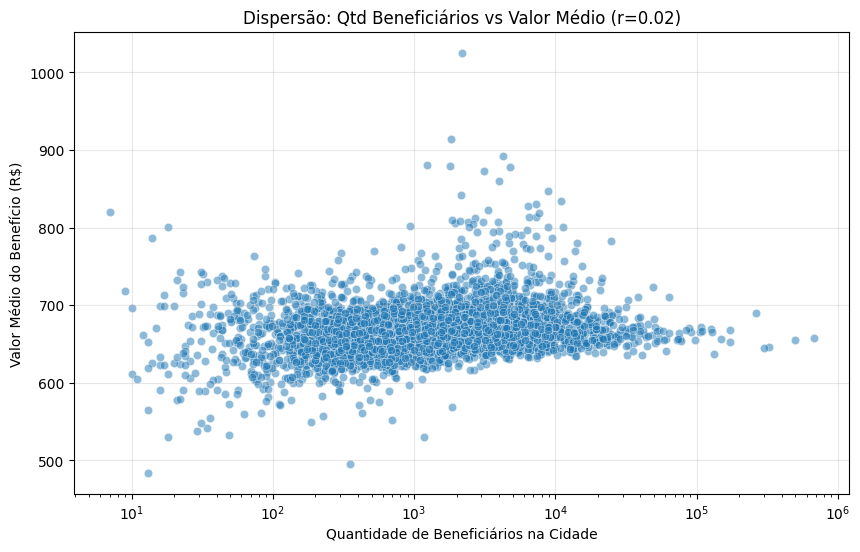

In [9]:
'''Gráfico de Dispersão'''

# Coletando os dados agregados para o gráfico
df_scatter = df_municipios.collect()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter.to_pandas(),
    x="Qtd_Beneficiarios",
    y="Valor_Medio_Pago",
    alpha=0.5
)

plt.title(f'Dispersão: Qtd Beneficiários vs Valor Médio (r={r:.2f})')
plt.xlabel('Quantidade de Beneficiários na Cidade')
plt.ylabel('Valor Médio do Benefício (R$)')
plt.grid(True, alpha=0.3)
plt.xscale('log') # Escala logarítmica ajuda a visualizar melhor quando há cidades gigantes (capitais) e minúsculas
plt.show()